# FASE 6 V2: Clasificacion direccional SVC en BVG (pipeline robusto)

Objetivo experimental:
- Mejorar senal, estabilidad y comparacion contra baselines en mercado de baja liquidez.
- Mantener rigor temporal (sin leakage, sin random split).
- Verificar si existe senal explotable bajo mejores condiciones metodologicas.

## 1) Diseno metodologico y reglas anti-leakage

Reglas implementadas en esta fase:
- Targets de horizonte: t+3 y t+5 (menos ruido microestructural que t+1).
- Features solo con informacion disponible hasta t (sin usar futuro).
- Validacion principal walk-forward expanding window.
- Validacion secundaria holdout 70/30 temporal.
- Baselines obligatorios: majority class y signo del retorno previo.
- Filtro de confianza calibrado con percentiles del train (P30/P70).
- Sin seleccion de modelos usando test.

In [1]:
# 2) Librerias
import importlib
import subprocess
import sys
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if importlib.util.find_spec('sklearn') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn'])
if importlib.util.find_spec('datasets') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets'])

from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 240)
sns.set_theme(style='whitegrid')

c:\Users\leynd\OneDrive\Escritorio\Tesis\implementaciones\desarrollov2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Carga de datos BVG

In [2]:
def canonical_col(name):
    txt = unicodedata.normalize('NFKD', str(name))
    txt = ''.join(ch for ch in txt if ord(ch) < 128)
    return txt.upper().strip()

def find_col(columns, expected):
    cmap = {canonical_col(c): c for c in columns}
    for key in expected:
        if key in cmap:
            return cmap[key]
    for c in columns:
        ccan = canonical_col(c)
        for key in expected:
            if key in ccan:
                return c
    raise KeyError(f'No se encontro columna para {expected}')

def load_raw_df():
    local_path = Path('papers') / 'BVG_Acciones_export.csv'
    if local_path.exists():
        return pd.read_csv(local_path, low_memory=False), 'csv_local'
    ds = load_dataset('beta3/Historical_Data_of_Ecuador_Stock_Exchange', 'default_stocks')
    return ds['stocks'].to_pandas(), 'huggingface_default_stocks'

df_raw, data_source = load_raw_df()
print('Fuente:', data_source)
print('Shape raw:', df_raw.shape)

emisor_col = find_col(df_raw.columns, ['EMISOR'])
fecha_col = find_col(df_raw.columns, ['FECHA NEGOCIACION', 'FECHA'])
precio_col = find_col(df_raw.columns, ['PRECIO', 'CLOSE'])

empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
empresas_can = [canonical_col(x) for x in empresas_objetivo]
mapper = dict(zip(empresas_can, empresas_objetivo))

df = df_raw.copy()
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df[precio_col] = pd.to_numeric(df[precio_col], errors='coerce')
df = df.dropna(subset=[emisor_col, fecha_col, precio_col]).copy()
df['_emisor_can'] = df[emisor_col].astype(str).map(canonical_col)
df = df[df['_emisor_can'].isin(empresas_can)].copy()
df['empresa'] = df['_emisor_can'].map(mapper)
df = df.sort_values(['empresa', fecha_col]).reset_index(drop=True)

print('Shape filtrado:', df.shape)
display(df[[fecha_col, 'empresa', precio_col]].head())

Fuente: huggingface_default_stocks
Shape raw: (28238, 11)
Shape filtrado: (18006, 13)


,FECHA NEGOCIACIÓN,empresa,PRECIO
0,2019-01-02,BANCO GUAYAQUIL S.A.,0.96
1,2019-01-03,BANCO GUAYAQUIL S.A.,0.96
2,2019-01-03,BANCO GUAYAQUIL S.A.,0.96
3,2019-01-14,BANCO GUAYAQUIL S.A.,0.96
4,2019-01-14,BANCO GUAYAQUIL S.A.,0.95


## 3) Feature engineering y targets (t+3, t+5)

Features obligatorias:
- Momentum: mom_3, mom_5
- Volatilidad: vol_5, vol_10
- Magnitud: abs_ret_1
- Actividad: days_since_trade
- Lags: ret_1, ret_2

In [11]:
HORIZONS = [3, 5]
NOISE_THRESHOLDS = [0.002, 0.005]
BASE_FEATURE_COLS = [
    'ret_1', 'ret_2', 'mom_3', 'mom_5',
    'vol_5', 'vol_10', 'abs_ret_1', 'days_since_trade'
]

def build_daily_panel(df_emp):
    d = (
        df_emp.sort_values(fecha_col)
        .groupby(fecha_col, as_index=True)[precio_col]
        .last()
        .to_frame('precio_trade_day')
        .sort_index()
    )
    d['ret'] = np.log(d['precio_trade_day'] / d['precio_trade_day'].shift(1))

    # Dias transcurridos entre sesiones con transaccion del emisor
    days_gap = d.index.to_series().diff().dt.days
    d['days_since_trade'] = days_gap.fillna(days_gap.median() if days_gap.notna().any() else 1).clip(lower=1)

    # Features de senal con informacion hasta t
    d['ret_1'] = d['ret'].shift(1)
    d['ret_2'] = d['ret'].shift(2)
    d['mom_3'] = d['ret'].shift(1).rolling(3).sum()
    d['mom_5'] = d['ret'].shift(1).rolling(5).sum()
    d['vol_5'] = d['ret'].shift(1).rolling(5).std()
    d['vol_10'] = d['ret'].shift(1).rolling(10).std()
    d['abs_ret_1'] = d['ret_1'].abs()

    # Baseline de signo previo
    d['baseline_sign_ret_prev'] = (d['ret_1'] > 0).astype(int)

    for h in HORIZONS:
        d[f'future_ret_t{h}'] = np.log(d['precio_trade_day'].shift(-h) / d['precio_trade_day'])
        d[f'y_t{h}'] = (d[f'future_ret_t{h}'] > 0).astype(int)

    return d.reset_index().rename(columns={fecha_col: 'fecha'})

rows = []
for empresa in empresas_objetivo:
    d_emp = df[df['empresa'] == empresa].copy()
    panel = build_daily_panel(d_emp)
    panel['empresa'] = empresa
    rows.append(panel)

df_features = pd.concat(rows, ignore_index=True)

# Lista para auditoria visual sin columnas duplicadas
required_cols_base = ['fecha', 'empresa', 'precio_trade_day', 'ret', 'ret_1', 'ret_2']
required_cols = list(dict.fromkeys(required_cols_base + BASE_FEATURE_COLS))
display(df_features[required_cols].head())
print('Muestras por empresa (antes de filtrar por horizonte/umbral):')
print(df_features.groupby('empresa').size().rename('n').to_string())

,fecha,empresa,precio_trade_day,ret,ret_1,ret_2,mom_3,mom_5,vol_5,vol_10,abs_ret_1,days_since_trade
0,2019-01-02,CORPORACION FAVORITA C.A.,2.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,2019-01-03,CORPORACION FAVORITA C.A.,2.46,0.008163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2019-01-04,CORPORACION FAVORITA C.A.,2.44,-0.008163,0.008163,NaN,NaN,NaN,NaN,NaN,0.008163,1.0
3,2019-01-07,CORPORACION FAVORITA C.A.,2.45,0.004090,-0.008163,0.008163,NaN,NaN,NaN,NaN,0.008163,3.0
4,2019-01-09,CORPORACION FAVORITA C.A.,2.44,-0.004090,0.004090,-0.008163,0.00409,NaN,NaN,NaN,0.004090,2.0


Muestras por empresa (antes de filtrar por horizonte/umbral):
empresa
BANCO GUAYAQUIL S.A.         1156
CORPORACION FAVORITA C.A.    1691


## 4) Utilidades de modelado y metricas

In [4]:
SVC_PARAM_GRID = {
    'linear': [{'C': c} for c in [0.1, 1, 10]],
    'rbf': [{'C': c, 'gamma': g} for c in [0.1, 1, 10] for g in ['scale', 0.1, 1]]
}

def cls_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }

def filtered_metrics(y_true, y_pred_filtered):
    mask = pd.notna(y_pred_filtered)
    n_total = len(y_true)
    n_oper = int(mask.sum())
    coverage = n_oper / n_total if n_total > 0 else np.nan
    if n_oper == 0:
        return {'coverage': coverage, 'accuracy_f': np.nan, 'precision_f': np.nan, 'recall_f': np.nan, 'f1_f': np.nan}
    yt = np.asarray(y_true)[mask]
    yp = np.asarray(y_pred_filtered)[mask].astype(int)
    return {
        'coverage': coverage,
        'accuracy_f': accuracy_score(yt, yp),
        'precision_f': precision_score(yt, yp, zero_division=0),
        'recall_f': recall_score(yt, yp, zero_division=0),
        'f1_f': f1_score(yt, yp, zero_division=0)
    }

def temporal_split(df_emp, train_frac=0.7):
    n = len(df_emp)
    split = int(n * train_frac)
    split = max(120, min(split, n - 40))
    return df_emp.iloc[:split].copy(), df_emp.iloc[split:].copy()

def train_with_internal_validation(train_df, feature_cols, target_col, model_type='linear', val_frac=0.2, min_val=35):
    n = len(train_df)
    val_size = max(min_val, int(n * val_frac))
    val_size = min(val_size, max(20, n // 3))
    split = n - val_size
    tr = train_df.iloc[:split].copy()
    va = train_df.iloc[split:].copy()

    X_tr = tr[feature_cols].values
    y_tr = tr[target_col].astype(int).values
    X_va = va[feature_cols].values
    y_va = va[target_col].astype(int).values

    best_params = None
    best_f1 = -np.inf

    for params in SVC_PARAM_GRID[model_type]:
        scaler = RobustScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_va_s = scaler.transform(X_va)

        if model_type == 'linear':
            clf = SVC(kernel='linear', C=params['C'], probability=True)
        else:
            clf = SVC(kernel='rbf', C=params['C'], gamma=params['gamma'], probability=True)

        clf.fit(X_tr_s, y_tr)
        y_va_pred = clf.predict(X_va_s)
        f1_val = f1_score(y_va, y_va_pred, zero_division=0)

        if f1_val > best_f1:
            best_f1 = f1_val
            best_params = params

    scaler_full = RobustScaler()
    X_train_full = train_df[feature_cols].values
    y_train_full = train_df[target_col].astype(int).values
    X_train_full_s = scaler_full.fit_transform(X_train_full)

    if model_type == 'linear':
        model = SVC(kernel='linear', C=best_params['C'], probability=True)
    else:
        model = SVC(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'], probability=True)

    model.fit(X_train_full_s, y_train_full)
    return model, scaler_full, best_params, best_f1

def confidence_filter_from_train_probs(prob_train, prob_test, y_pred_hard):
    # Calibracion de umbrales usando distribucion de probabilidad del train
    lower = float(np.nanpercentile(prob_train, 30))
    upper = float(np.nanpercentile(prob_train, 70))
    if lower > upper:
        lower, upper = upper, lower

    y_pred_filtered = np.full(len(prob_test), np.nan)
    y_pred_filtered[prob_test >= upper] = 1
    y_pred_filtered[prob_test <= lower] = 0

    return y_pred_filtered, lower, upper

def build_sign_baseline_probs(train_df, test_df, target_col):
    train_tmp = train_df[['ret_1', target_col]].copy()
    p_up_if_pos = train_tmp.loc[train_tmp['ret_1'] > 0, target_col].mean()
    p_up_if_nonpos = train_tmp.loc[train_tmp['ret_1'] <= 0, target_col].mean()
    p_global = float(train_df[target_col].mean())

    if pd.isna(p_up_if_pos):
        p_up_if_pos = p_global
    if pd.isna(p_up_if_nonpos):
        p_up_if_nonpos = p_global

    prob_train = np.where(train_df['ret_1'].values > 0, p_up_if_pos, p_up_if_nonpos)
    prob_test = np.where(test_df['ret_1'].values > 0, p_up_if_pos, p_up_if_nonpos)
    y_pred_hard = (prob_test >= 0.5).astype(int)
    return prob_train.astype(float), prob_test.astype(float), y_pred_hard

## 5) Walk-forward principal (expanding window)

In [5]:
def run_walk_forward_case(df_case, feature_cols, target_col, initial_train=220, test_size=30, step_size=30):
    d = df_case.sort_values('fecha').reset_index(drop=True).copy()
    n = len(d)

    if n < (initial_train + test_size + 1):
        initial_train = max(140, int(n * 0.55))
        test_size = max(20, int(n * 0.15))
        step_size = test_size

    rows = []
    pred_rows = []
    window_id = 0
    train_end = initial_train

    while (train_end + test_size) <= n:
        train = d.iloc[:train_end].copy()
        test = d.iloc[train_end:train_end + test_size].copy()

        y_train = train[target_col].astype(int).values
        y_test = test[target_col].astype(int).values

        # Baseline 1: majority
        p_up_majority = float(np.mean(y_train))
        prob_train_maj = np.full(len(train), p_up_majority, dtype=float)
        prob_test_maj = np.full(len(test), p_up_majority, dtype=float)
        y_pred_maj = (prob_test_maj >= 0.5).astype(int)
        y_pred_f_maj, low_maj, up_maj = confidence_filter_from_train_probs(prob_train_maj, prob_test_maj, y_pred_maj)

        m_full_maj = cls_metrics(y_test, y_pred_maj)
        m_f_maj = filtered_metrics(y_test, y_pred_f_maj)
        rows.append({
            'window_id': window_id, 'model': 'baseline_majority', 'n_train': len(train), 'n_test': len(test),
            'conf_low': low_maj, 'conf_high': up_maj, **m_full_maj, **m_f_maj
        })

        # Baseline 2: signo del retorno previo
        prob_train_sign, prob_test_sign, y_pred_sign = build_sign_baseline_probs(train, test, target_col)
        y_pred_f_sign, low_sign, up_sign = confidence_filter_from_train_probs(prob_train_sign, prob_test_sign, y_pred_sign)

        m_full_sign = cls_metrics(y_test, y_pred_sign)
        m_f_sign = filtered_metrics(y_test, y_pred_f_sign)
        rows.append({
            'window_id': window_id, 'model': 'baseline_sign_ret_prev', 'n_train': len(train), 'n_test': len(test),
            'conf_low': low_sign, 'conf_high': up_sign, **m_full_sign, **m_f_sign
        })

        # Modelos SVC
        for model_type in ['linear', 'rbf']:
            model_name = f'svc_{model_type}'
            model, scaler, best_params, best_val_f1 = train_with_internal_validation(train, feature_cols, target_col, model_type)

            X_train_s = scaler.transform(train[feature_cols].values)
            X_test_s = scaler.transform(test[feature_cols].values)

            y_pred = model.predict(X_test_s)
            prob_train = model.predict_proba(X_train_s)[:, 1]
            prob_test = model.predict_proba(X_test_s)[:, 1]
            y_pred_f, low, up = confidence_filter_from_train_probs(prob_train, prob_test, y_pred)

            m_full = cls_metrics(y_test, y_pred)
            m_f = filtered_metrics(y_test, y_pred_f)

            rows.append({
                'window_id': window_id, 'model': model_name, 'n_train': len(train), 'n_test': len(test),
                'best_params': str(best_params), 'best_val_f1': float(best_val_f1),
                'conf_low': low, 'conf_high': up,
                **m_full, **m_f
            })

            for i, (_, r) in enumerate(test.iterrows()):
                pred_rows.append({
                    'window_id': window_id,
                    'fecha': r['fecha'],
                    'empresa': r['empresa'],
                    'horizon': int(r['horizon']),
                    'noise_thr': float(r['noise_thr']),
                    'precio_trade_day': float(r['precio_trade_day']),
                    'model': model_name,
                    'y_true': int(y_test[i]),
                    'y_pred_hard': int(y_pred[i]),
                    'y_pred_filtered': y_pred_f[i],
                    'prob_up': float(prob_test[i]),
                    'confidence': float(max(prob_test[i], 1 - prob_test[i]))
                })

        window_id += 1
        train_end += step_size

    return pd.DataFrame(rows), pd.DataFrame(pred_rows)

all_wf_rows = []
all_wf_pred_rows = []

for empresa in empresas_objetivo:
    d_emp = df_features[df_features['empresa'] == empresa].copy().sort_values('fecha').reset_index(drop=True)

    for h in HORIZONS:
        target_col = f'y_t{h}'
        for thr in NOISE_THRESHOLDS:
            d_case = d_emp[d_emp['abs_ret_1'] >= thr].copy()
            d_case['horizon'] = h
            d_case['noise_thr'] = thr
            d_case = d_case.dropna(subset=BASE_FEATURE_COLS + [target_col]).copy()
            d_case = d_case.sort_values('fecha').reset_index(drop=True)

            if len(d_case) < 220:
                continue

            res_wf, pred_wf = run_walk_forward_case(d_case, BASE_FEATURE_COLS, target_col)
            if res_wf.empty:
                continue

            res_wf['empresa'] = empresa
            res_wf['horizon'] = h
            res_wf['noise_thr'] = thr

            all_wf_rows.append(res_wf)
            if not pred_wf.empty:
                all_wf_pred_rows.append(pred_wf)

wf_df = pd.concat(all_wf_rows, ignore_index=True) if all_wf_rows else pd.DataFrame()
wf_preds_df = pd.concat(all_wf_pred_rows, ignore_index=True) if all_wf_pred_rows else pd.DataFrame()

print('Walk-forward rows:', wf_df.shape)
display(wf_df.head())

Walk-forward rows: (616, 20)


,window_id,model,n_train,n_test,conf_low,conf_high,accuracy,precision,recall,f1,coverage,accuracy_f,precision_f,recall_f,f1_f,best_params,best_val_f1,empresa,horizon,noise_thr
0,0,baseline_majority,220,30,0.409091,0.409091,0.800000,0.000000,0.000000,0.000000,1.000000,0.800000,0.000000,0.000000,0.000000,NaN,NaN,CORPORACION FAVORITA C.A.,3,0.002
1,0,baseline_sign_ret_prev,220,30,0.346154,0.465517,0.800000,0.000000,0.000000,0.000000,1.000000,0.533333,0.166667,0.333333,0.222222,NaN,NaN,CORPORACION FAVORITA C.A.,3,0.002
2,0,svc_linear,220,30,0.401912,0.409770,0.800000,0.000000,0.000000,0.000000,0.600000,0.333333,0.200000,1.000000,0.333333,{'C': 0.1},0.000,CORPORACION FAVORITA C.A.,3,0.002
3,0,svc_rbf,220,30,0.402284,0.411667,0.533333,0.166667,0.333333,0.222222,0.733333,0.363636,0.200000,0.600000,0.300000,"{'C': 10, 'gamma': 0.1}",0.375,CORPORACION FAVORITA C.A.,3,0.002
4,1,baseline_majority,250,30,0.384000,0.384000,0.400000,0.000000,0.000000,0.000000,1.000000,0.400000,0.000000,0.000000,0.000000,NaN,NaN,CORPORACION FAVORITA C.A.,3,0.002


## 6) Holdout temporal 70/30 (comparativo secundario)

In [6]:
def run_holdout_case(df_case, feature_cols, target_col):
    d = df_case.sort_values('fecha').reset_index(drop=True).copy()
    train, test = temporal_split(d, train_frac=0.7)

    y_train = train[target_col].astype(int).values
    y_test = test[target_col].astype(int).values

    rows = []

    # Baseline majority
    p_up_majority = float(np.mean(y_train))
    prob_train_maj = np.full(len(train), p_up_majority, dtype=float)
    prob_test_maj = np.full(len(test), p_up_majority, dtype=float)
    y_pred_maj = (prob_test_maj >= 0.5).astype(int)
    y_pred_f_maj, low_maj, up_maj = confidence_filter_from_train_probs(prob_train_maj, prob_test_maj, y_pred_maj)
    rows.append({
        'model': 'baseline_majority', 'split': 'holdout', 'conf_low': low_maj, 'conf_high': up_maj,
        **cls_metrics(y_test, y_pred_maj), **filtered_metrics(y_test, y_pred_f_maj)
    })

    # Baseline signo
    prob_train_sign, prob_test_sign, y_pred_sign = build_sign_baseline_probs(train, test, target_col)
    y_pred_f_sign, low_sign, up_sign = confidence_filter_from_train_probs(prob_train_sign, prob_test_sign, y_pred_sign)
    rows.append({
        'model': 'baseline_sign_ret_prev', 'split': 'holdout', 'conf_low': low_sign, 'conf_high': up_sign,
        **cls_metrics(y_test, y_pred_sign), **filtered_metrics(y_test, y_pred_f_sign)
    })

    for model_type in ['linear', 'rbf']:
        model_name = f'svc_{model_type}'
        model, scaler, best_params, best_val_f1 = train_with_internal_validation(train, feature_cols, target_col, model_type)

        X_train_s = scaler.transform(train[feature_cols].values)
        X_test_s = scaler.transform(test[feature_cols].values)

        y_pred = model.predict(X_test_s)
        prob_train = model.predict_proba(X_train_s)[:, 1]
        prob_test = model.predict_proba(X_test_s)[:, 1]
        y_pred_f, low, up = confidence_filter_from_train_probs(prob_train, prob_test, y_pred)

        rows.append({
            'model': model_name,
            'split': 'holdout',
            'best_params': str(best_params),
            'best_val_f1': float(best_val_f1),
            'conf_low': low,
            'conf_high': up,
            **cls_metrics(y_test, y_pred),
            **filtered_metrics(y_test, y_pred_f)
        })

    return pd.DataFrame(rows)

all_holdout_rows = []

for empresa in empresas_objetivo:
    d_emp = df_features[df_features['empresa'] == empresa].copy().sort_values('fecha').reset_index(drop=True)

    for h in HORIZONS:
        target_col = f'y_t{h}'
        for thr in NOISE_THRESHOLDS:
            d_case = d_emp[d_emp['abs_ret_1'] >= thr].copy()
            d_case['horizon'] = h
            d_case['noise_thr'] = thr
            d_case = d_case.dropna(subset=BASE_FEATURE_COLS + [target_col]).copy()
            d_case = d_case.sort_values('fecha').reset_index(drop=True)

            if len(d_case) < 220:
                continue

            hres = run_holdout_case(d_case, BASE_FEATURE_COLS, target_col)
            hres['empresa'] = empresa
            hres['horizon'] = h
            hres['noise_thr'] = thr
            all_holdout_rows.append(hres)

holdout_df = pd.concat(all_holdout_rows, ignore_index=True) if all_holdout_rows else pd.DataFrame()
print('Holdout rows:', holdout_df.shape)
display(holdout_df.head())

Holdout rows: (32, 18)


,model,split,conf_low,conf_high,accuracy,precision,recall,f1,coverage,accuracy_f,precision_f,recall_f,f1_f,best_params,best_val_f1,empresa,horizon,noise_thr
0,baseline_majority,holdout,0.379043,0.379043,0.689759,0.00000,0.000000,0.000000,1.000000,0.689759,0.000000,0.000000,0.000000,NaN,NaN,CORPORACION FAVORITA C.A.,3,0.002
1,baseline_sign_ret_prev,holdout,0.335065,0.422680,0.689759,0.00000,0.000000,0.000000,1.000000,0.521084,0.329268,0.524272,0.404494,NaN,NaN,CORPORACION FAVORITA C.A.,3,0.002
2,svc_linear,holdout,0.379365,0.381036,0.689759,0.00000,0.000000,0.000000,0.629518,0.440191,0.330882,0.633803,0.434783,{'C': 0.1},0.00000,CORPORACION FAVORITA C.A.,3,0.002
3,svc_rbf,holdout,0.378140,0.382033,0.629518,0.34375,0.213592,0.263473,0.268072,0.370787,0.222222,0.461538,0.300000,"{'C': 10, 'gamma': 1}",0.25641,CORPORACION FAVORITA C.A.,3,0.002
4,baseline_majority,holdout,0.376623,0.376623,0.693966,0.00000,0.000000,0.000000,1.000000,0.693966,0.000000,0.000000,0.000000,NaN,NaN,CORPORACION FAVORITA C.A.,3,0.005


## 7) Resumen de resultados, estabilidad y comparacion contra baselines

In [7]:
if wf_df.empty:
    raise ValueError('No hay resultados walk-forward. Revisa tamano de muestra despues de filtros.')

wf_summary = (
    wf_df.groupby(['empresa', 'horizon', 'noise_thr', 'model']).agg(
        n_windows=('window_id', 'count'),
        accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
        f1_mean=('f1', 'mean'), f1_std=('f1', 'std'),
        accuracy_f_mean=('accuracy_f', 'mean'), accuracy_f_std=('accuracy_f', 'std'),
        f1_f_mean=('f1_f', 'mean'), f1_f_std=('f1_f', 'std'),
        coverage_mean=('coverage', 'mean'), coverage_std=('coverage', 'std')
    ).reset_index()
)

display(wf_summary.sort_values(['empresa', 'horizon', 'noise_thr', 'f1_f_mean'], ascending=[True, True, True, False]))

cmp_rows = []
svc_models = ['svc_linear', 'svc_rbf']
baseline_models = ['baseline_majority', 'baseline_sign_ret_prev']

for empresa in wf_df['empresa'].unique():
    d_emp = wf_df[wf_df['empresa'] == empresa]
    for h in sorted(d_emp['horizon'].unique()):
        d_h = d_emp[d_emp['horizon'] == h]
        for thr in sorted(d_h['noise_thr'].unique()):
            d_case = d_h[d_h['noise_thr'] == thr]
            for svc_m in svc_models:
                d_svc = d_case[d_case['model'] == svc_m].sort_values('window_id')
                for base_m in baseline_models:
                    d_base = d_case[d_case['model'] == base_m].sort_values('window_id')
                    m = d_svc[['window_id', 'accuracy', 'f1', 'accuracy_f', 'f1_f']].merge(
                        d_base[['window_id', 'accuracy', 'f1', 'accuracy_f', 'f1_f']],
                        on='window_id', suffixes=('_svc', '_base')
                    )
                    if m.empty:
                        continue

                    cmp_rows.append({
                        'empresa': empresa,
                        'horizon': int(h),
                        'noise_thr': float(thr),
                        'svc_model': svc_m,
                        'baseline_model': base_m,
                        'n_windows': len(m),
                        'delta_acc_mean': float((m['accuracy_svc'] - m['accuracy_base']).mean()),
                        'delta_f1_mean': float((m['f1_svc'] - m['f1_base']).mean()),
                        'delta_acc_f_mean': float((m['accuracy_f_svc'] - m['accuracy_f_base']).mean()),
                        'delta_f1_f_mean': float((m['f1_f_svc'] - m['f1_f_base']).mean()),
                        'pct_windows_acc_better': float((m['accuracy_svc'] > m['accuracy_base']).mean() * 100),
                        'pct_windows_f1_better': float((m['f1_svc'] > m['f1_base']).mean() * 100),
                        'pct_windows_acc_f_better': float((m['accuracy_f_svc'] > m['accuracy_f_base']).mean() * 100),
                        'pct_windows_f1_f_better': float((m['f1_f_svc'] > m['f1_f_base']).mean() * 100)
                    })

wf_cmp_df = pd.DataFrame(cmp_rows)
display(wf_cmp_df.sort_values(['empresa', 'horizon', 'noise_thr', 'svc_model', 'baseline_model']))

if not holdout_df.empty:
    display(holdout_df.sort_values(['empresa', 'horizon', 'noise_thr', 'f1_f'], ascending=[True, True, True, False]))

,empresa,horizon,noise_thr,model,n_windows,accuracy_mean,accuracy_std,f1_mean,f1_std,accuracy_f_mean,accuracy_f_std,f1_f_mean,f1_f_std,coverage_mean,coverage_std
1,BANCO GUAYAQUIL S.A.,3,0.002,baseline_sign_ret_prev,15,0.551111,0.182081,0.000000,0.000000,0.484444,0.112593,0.441516,0.175665,1.000000,0.000000
3,BANCO GUAYAQUIL S.A.,3,0.002,svc_rbf,15,0.586667,0.095784,0.309627,0.214188,0.506081,0.169321,0.435309,0.247256,0.595556,0.246842
2,BANCO GUAYAQUIL S.A.,3,0.002,svc_linear,15,0.551111,0.182081,0.000000,0.000000,0.423096,0.150521,0.387358,0.153448,0.535556,0.170185
0,BANCO GUAYAQUIL S.A.,3,0.002,baseline_majority,15,0.551111,0.182081,0.000000,0.000000,0.551111,0.182081,0.000000,0.000000,1.000000,0.000000
5,BANCO GUAYAQUIL S.A.,3,0.005,baseline_sign_ret_prev,15,0.551111,0.182081,0.000000,0.000000,0.484444,0.112593,0.441516,0.175665,1.000000,0.000000
6,BANCO GUAYAQUIL S.A.,3,0.005,svc_linear,15,0.551111,0.182081,0.000000,0.000000,0.494319,0.170172,0.437827,0.209410,0.535556,0.170185
7,BANCO GUAYAQUIL S.A.,3,0.005,svc_rbf,15,0.586667,0.095784,0.309627,0.214188,0.520574,0.168094,0.419653,0.255809,0.595556,0.246842
4,BANCO GUAYAQUIL S.A.,3,0.005,baseline_majority,15,0.551111,0.182081,0.000000,0.000000,0.551111,0.182081,0.000000,0.000000,1.000000,0.000000
10,BANCO GUAYAQUIL S.A.,5,0.002,svc_linear,15,0.522222,0.227361,0.000000,0.000000,0.475863,0.221581,0.494641,0.223090,0.528889,0.158298
11,BANCO GUAYAQUIL S.A.,5,0.002,svc_rbf,15,0.542222,0.113015,0.273949,0.180537,0.488041,0.200586,0.431133,0.246504,0.462222,0.201529


,empresa,horizon,noise_thr,svc_model,baseline_model,n_windows,delta_acc_mean,delta_f1_mean,delta_acc_f_mean,delta_f1_f_mean,pct_windows_acc_better,pct_windows_f1_better,pct_windows_acc_f_better,pct_windows_f1_f_better
16,BANCO GUAYAQUIL S.A.,3,0.002,svc_linear,baseline_majority,15,0.000000e+00,0.000000,-0.128015,0.387358,0.000000,0.000000,20.000000,100.000000
17,BANCO GUAYAQUIL S.A.,3,0.002,svc_linear,baseline_sign_ret_prev,15,0.000000e+00,0.000000,-0.061349,-0.054158,0.000000,0.000000,40.000000,40.000000
18,BANCO GUAYAQUIL S.A.,3,0.002,svc_rbf,baseline_majority,15,3.555556e-02,0.309627,-0.045030,0.435309,53.333333,80.000000,40.000000,86.666667
19,BANCO GUAYAQUIL S.A.,3,0.002,svc_rbf,baseline_sign_ret_prev,15,3.555556e-02,0.309627,0.021637,-0.006207,53.333333,80.000000,60.000000,66.666667
20,BANCO GUAYAQUIL S.A.,3,0.005,svc_linear,baseline_majority,15,0.000000e+00,0.000000,-0.056792,0.437827,0.000000,0.000000,33.333333,100.000000
21,BANCO GUAYAQUIL S.A.,3,0.005,svc_linear,baseline_sign_ret_prev,15,0.000000e+00,0.000000,0.009875,-0.003689,0.000000,0.000000,60.000000,53.333333
22,BANCO GUAYAQUIL S.A.,3,0.005,svc_rbf,baseline_majority,15,3.555556e-02,0.309627,-0.030537,0.419653,53.333333,80.000000,40.000000,86.666667
23,BANCO GUAYAQUIL S.A.,3,0.005,svc_rbf,baseline_sign_ret_prev,15,3.555556e-02,0.309627,0.036129,-0.021863,53.333333,80.000000,66.666667,60.000000
24,BANCO GUAYAQUIL S.A.,5,0.002,svc_linear,baseline_majority,15,0.000000e+00,0.000000,-0.046359,0.494641,0.000000,0.000000,40.000000,93.333333
25,BANCO GUAYAQUIL S.A.,5,0.002,svc_linear,baseline_sign_ret_prev,15,0.000000e+00,0.000000,-0.006359,0.064173,0.000000,0.000000,53.333333,53.333333


,model,split,conf_low,conf_high,accuracy,precision,recall,f1,coverage,accuracy_f,precision_f,recall_f,f1_f,best_params,best_val_f1,empresa,horizon,noise_thr
18,svc_linear,holdout,0.343050,0.353987,0.428571,0.000000,0.000000,0.000000,0.395238,0.590361,0.697674,0.588235,0.638298,{'C': 0.1},0.000000,BANCO GUAYAQUIL S.A.,3,0.002
17,baseline_sign_ret_prev,holdout,0.326613,0.358333,0.428571,0.000000,0.000000,0.000000,1.000000,0.495238,0.552239,0.616667,0.582677,NaN,NaN,BANCO GUAYAQUIL S.A.,3,0.002
19,svc_rbf,holdout,0.285331,0.475286,0.485714,0.642857,0.225000,0.333333,0.366667,0.454545,0.777778,0.148936,0.250000,"{'C': 10, 'gamma': 1}",0.400000,BANCO GUAYAQUIL S.A.,3,0.002
16,baseline_majority,holdout,0.342213,0.342213,0.428571,0.000000,0.000000,0.000000,1.000000,0.428571,0.000000,0.000000,0.000000,NaN,NaN,BANCO GUAYAQUIL S.A.,3,0.002
21,baseline_sign_ret_prev,holdout,0.325203,0.357143,0.432692,0.000000,0.000000,0.000000,1.000000,0.490385,0.546154,0.601695,0.572581,NaN,NaN,BANCO GUAYAQUIL S.A.,3,0.005
22,svc_linear,holdout,0.340815,0.344102,0.432692,0.000000,0.000000,0.000000,0.586538,0.467213,0.583333,0.202899,0.301075,{'C': 0.1},0.000000,BANCO GUAYAQUIL S.A.,3,0.005
23,svc_rbf,holdout,0.267289,0.522845,0.485577,0.641026,0.211864,0.318471,0.365385,0.447368,0.777778,0.148936,0.250000,"{'C': 10, 'gamma': 1}",0.424242,BANCO GUAYAQUIL S.A.,3,0.005
20,baseline_majority,holdout,0.340909,0.340909,0.432692,0.000000,0.000000,0.000000,1.000000,0.432692,0.000000,0.000000,0.000000,NaN,NaN,BANCO GUAYAQUIL S.A.,3,0.005
25,baseline_sign_ret_prev,holdout,0.362903,0.366667,0.395238,0.000000,0.000000,0.000000,1.000000,0.547619,0.619403,0.653543,0.636015,NaN,NaN,BANCO GUAYAQUIL S.A.,5,0.002
26,svc_linear,holdout,0.366143,0.366598,0.395238,0.000000,0.000000,0.000000,0.409524,0.500000,0.578947,0.634615,0.605505,{'C': 0.1},0.000000,BANCO GUAYAQUIL S.A.,5,0.002


## 8) Seleccion de mejor configuracion por empresa (solo para reporte y visualizacion)

Nota: la evaluacion principal sigue siendo walk-forward. Esta seleccion NO reentrena con test.
Se usa para identificar que configuracion fue mas defendible en estabilidad + ganancia vs baseline.

In [8]:
# Baseline mas fuerte por caso usando F1 filtrado promedio
base_best = (
    wf_summary[wf_summary['model'].isin(['baseline_majority', 'baseline_sign_ret_prev'])]
    .sort_values(['empresa', 'horizon', 'noise_thr', 'f1_f_mean'], ascending=[True, True, True, False])
    .groupby(['empresa', 'horizon', 'noise_thr'], as_index=False)
    .first()[['empresa', 'horizon', 'noise_thr', 'model']]
    .rename(columns={'model': 'best_baseline_model'})
)

svc_summary = wf_summary[wf_summary['model'].isin(['svc_linear', 'svc_rbf'])].copy()
svc_eval = svc_summary.merge(base_best, on=['empresa', 'horizon', 'noise_thr'], how='left')

cmp_best_base = wf_cmp_df.rename(columns={'baseline_model': 'best_baseline_model'}).copy()
svc_eval = svc_eval.merge(
    cmp_best_base[['empresa', 'horizon', 'noise_thr', 'svc_model', 'best_baseline_model', 'delta_f1_f_mean', 'pct_windows_f1_f_better', 'pct_windows_acc_f_better']],
    left_on=['empresa', 'horizon', 'noise_thr', 'model', 'best_baseline_model'],
    right_on=['empresa', 'horizon', 'noise_thr', 'svc_model', 'best_baseline_model'],
    how='left'
)

# Score cuantitativo para priorizar ganancia filtrada + consistencia + estabilidad
svc_eval['stability_penalty'] = svc_eval['f1_f_std'].fillna(0.0)
svc_eval['selection_score'] = (
    svc_eval['delta_f1_f_mean'].fillna(-1.0) * 100
    + svc_eval['pct_windows_f1_f_better'].fillna(0.0) * 0.3
    + svc_eval['coverage_mean'].fillna(0.0) * 10
    - svc_eval['stability_penalty'].fillna(0.0) * 30
)

best_config_rows = []
for empresa in empresas_objetivo:
    s = svc_eval[svc_eval['empresa'] == empresa].copy()
    if s.empty:
        continue
    best = s.sort_values(['selection_score', 'f1_f_mean'], ascending=False).iloc[0]
    best_config_rows.append(best)

best_config_df = pd.DataFrame(best_config_rows)
display(best_config_df[['empresa', 'model', 'horizon', 'noise_thr', 'best_baseline_model', 'delta_f1_f_mean', 'pct_windows_f1_f_better', 'f1_f_mean', 'f1_f_std', 'coverage_mean', 'selection_score']])

,empresa,model,horizon,noise_thr,best_baseline_model,delta_f1_f_mean,pct_windows_f1_f_better,f1_f_mean,f1_f_std,coverage_mean,selection_score
14,CORPORACION FAVORITA C.A.,svc_linear,5,0.005,baseline_sign_ret_prev,0.045136,66.666667,0.474932,0.175221,0.637037,25.627319
4,BANCO GUAYAQUIL S.A.,svc_linear,5,0.002,baseline_sign_ret_prev,0.064173,53.333333,0.494641,0.223090,0.528889,21.013453


## 9) Visualizacion obligatoria: precio + decisiones filtradas

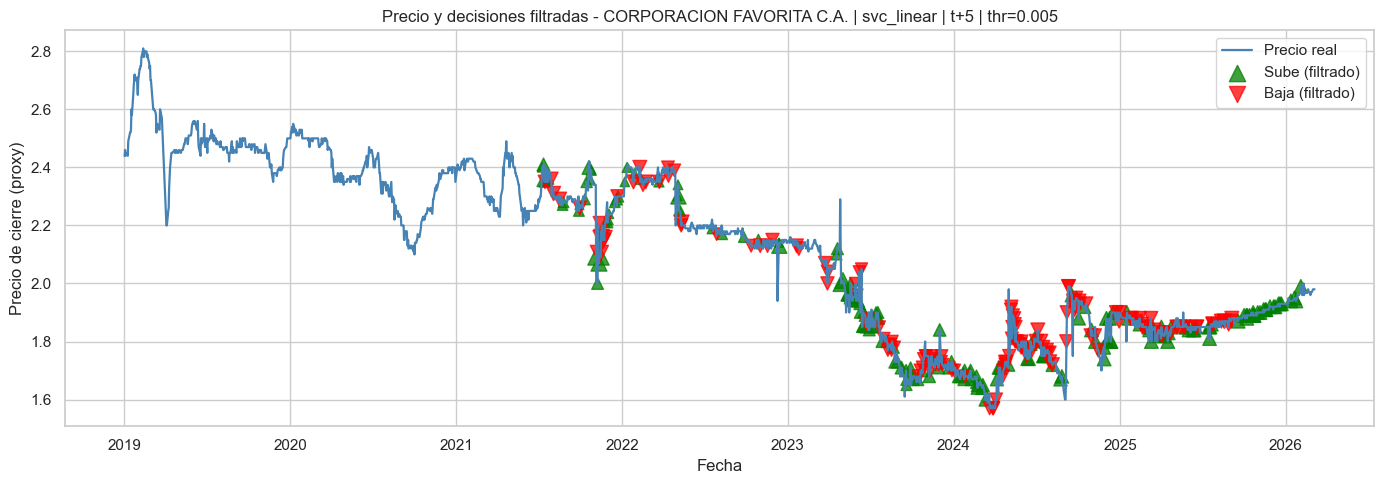

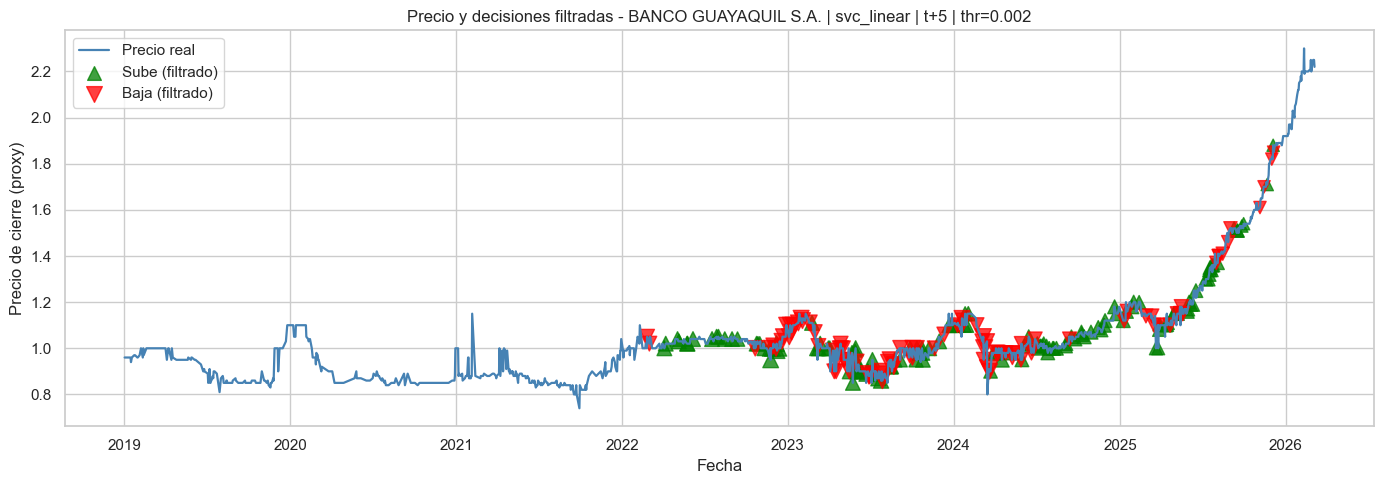

In [9]:
if wf_preds_df.empty:
    raise ValueError('No hay predicciones walk-forward para graficar.')

for _, row in best_config_df.iterrows():
    empresa = row['empresa']
    best_model = row['model']
    h = int(row['horizon'])
    thr = float(row['noise_thr'])

    base_price = (
        df_features[df_features['empresa'] == empresa][['fecha', 'precio_trade_day']]
        .drop_duplicates(subset=['fecha'])
        .sort_values('fecha')
    )

    pred_best = wf_preds_df[
        (wf_preds_df['empresa'] == empresa) &
        (wf_preds_df['model'] == best_model) &
        (wf_preds_df['horizon'] == h) &
        (wf_preds_df['noise_thr'] == thr)
    ].copy()

    pred_best = pred_best[pd.notna(pred_best['y_pred_filtered'])].copy()
    up = pred_best[pred_best['y_pred_filtered'] == 1].copy()
    down = pred_best[pred_best['y_pred_filtered'] == 0].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(base_price['fecha'], base_price['precio_trade_day'], color='steelblue', linewidth=1.6, label='Precio real')

    if not up.empty:
        size_up = 40 + 220 * (up['confidence'] - 0.5).clip(lower=0) * 2
        plt.scatter(up['fecha'], up['precio_trade_day'], s=size_up, marker='^', color='green', alpha=0.75, label='Sube (filtrado)')

    if not down.empty:
        size_down = 40 + 220 * (down['confidence'] - 0.5).clip(lower=0) * 2
        plt.scatter(down['fecha'], down['precio_trade_day'], s=size_down, marker='v', color='red', alpha=0.75, label='Baja (filtrado)')

    plt.title(f'Precio y decisiones filtradas - {empresa} | {best_model} | t+{h} | thr={thr}')
    plt.xlabel('Fecha')
    plt.ylabel('Precio de cierre (proxy)')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

## 10) Analisis final automatico por empresa (logica cuantitativa)

In [10]:
print('=== ANALISIS FINAL AUTOMATICO ===')

final_rows = []
for _, r in best_config_df.iterrows():
    empresa = r['empresa']
    best_model = r['model']
    h = int(r['horizon'])
    thr = float(r['noise_thr'])
    best_baseline = r['best_baseline_model']

    svc_row = wf_summary[
        (wf_summary['empresa'] == empresa) &
        (wf_summary['horizon'] == h) &
        (wf_summary['noise_thr'] == thr) &
        (wf_summary['model'] == best_model)
    ].iloc[0]

    base_row = wf_summary[
        (wf_summary['empresa'] == empresa) &
        (wf_summary['horizon'] == h) &
        (wf_summary['noise_thr'] == thr) &
        (wf_summary['model'] == best_baseline)
    ].iloc[0]

    cmp_row = wf_cmp_df[
        (wf_cmp_df['empresa'] == empresa) &
        (wf_cmp_df['horizon'] == h) &
        (wf_cmp_df['noise_thr'] == thr) &
        (wf_cmp_df['svc_model'] == best_model) &
        (wf_cmp_df['baseline_model'] == best_baseline)
    ].iloc[0]

    improve_vs_baseline = (svc_row['f1_f_mean'] > base_row['f1_f_mean']) and (svc_row['accuracy_f_mean'] > base_row['accuracy_f_mean'])
    consistency = (cmp_row['pct_windows_f1_f_better'] >= 60.0) and (cmp_row['pct_windows_acc_f_better'] >= 60.0)
    stability = (svc_row['f1_f_std'] <= 0.10) and (svc_row['accuracy_f_std'] <= 0.10)
    filter_improves_quality = (svc_row['f1_f_mean'] > svc_row['f1_mean']) and (svc_row['accuracy_f_mean'] > svc_row['accuracy_mean'])
    usable_real = improve_vs_baseline and consistency and stability and (svc_row['coverage_mean'] >= 0.35)

    print('')
    print(f'Empresa: {empresa}')
    print(f'- Configuracion seleccionada: {best_model} | horizonte t+{h} | noise_thr={thr}')
    print(f'- Baseline comparado: {best_baseline}')
    print(f"1) Mejora frente baseline?: {'SI' if improve_vs_baseline else 'NO'}")
    print(f"2) Es consistente por ventanas?: {'SI' if consistency else 'NO'}")
    print(f"3) Es estable?: {'SI' if stability else 'NO'}")
    print(f"4) El filtro mejora calidad?: {'SI' if filter_improves_quality else 'NO'}")
    print(f"5) Es usable en sistema real?: {'SI' if usable_real else 'NO'}")

    final_rows.append({
        'empresa': empresa,
        'best_model': best_model,
        'horizon': h,
        'noise_thr': thr,
        'baseline_ref': best_baseline,
        'f1_f_mean_svc': float(svc_row['f1_f_mean']),
        'f1_f_mean_baseline': float(base_row['f1_f_mean']),
        'delta_f1_f': float(svc_row['f1_f_mean'] - base_row['f1_f_mean']),
        'accuracy_f_mean_svc': float(svc_row['accuracy_f_mean']),
        'accuracy_f_mean_baseline': float(base_row['accuracy_f_mean']),
        'delta_accuracy_f': float(svc_row['accuracy_f_mean'] - base_row['accuracy_f_mean']),
        'pct_windows_f1_f_better': float(cmp_row['pct_windows_f1_f_better']),
        'pct_windows_acc_f_better': float(cmp_row['pct_windows_acc_f_better']),
        'f1_f_std': float(svc_row['f1_f_std']) if pd.notna(svc_row['f1_f_std']) else np.nan,
        'accuracy_f_std': float(svc_row['accuracy_f_std']) if pd.notna(svc_row['accuracy_f_std']) else np.nan,
        'coverage_mean': float(svc_row['coverage_mean']) if pd.notna(svc_row['coverage_mean']) else np.nan,
        'improve_vs_baseline_flag': 'yes' if improve_vs_baseline else 'no',
        'consistency_flag': 'yes' if consistency else 'no',
        'stability_flag': 'yes' if stability else 'no',
        'filter_quality_flag': 'yes' if filter_improves_quality else 'no',
        'usable_real_system_flag': 'yes' if usable_real else 'no'
    })

final_summary_df = pd.DataFrame(final_rows)
print('\n=== TABLA FINAL ===')
display(final_summary_df)

=== ANALISIS FINAL AUTOMATICO ===

Empresa: CORPORACION FAVORITA C.A.
- Configuracion seleccionada: svc_linear | horizonte t+5 | noise_thr=0.005
- Baseline comparado: baseline_sign_ret_prev
1) Mejora frente baseline?: NO
2) Es consistente por ventanas?: NO
3) Es estable?: NO
4) El filtro mejora calidad?: NO
5) Es usable en sistema real?: NO

Empresa: BANCO GUAYAQUIL S.A.
- Configuracion seleccionada: svc_linear | horizonte t+5 | noise_thr=0.002
- Baseline comparado: baseline_sign_ret_prev
1) Mejora frente baseline?: NO
2) Es consistente por ventanas?: NO
3) Es estable?: NO
4) El filtro mejora calidad?: NO
5) Es usable en sistema real?: NO

=== TABLA FINAL ===


,empresa,best_model,horizon,noise_thr,baseline_ref,f1_f_mean_svc,f1_f_mean_baseline,delta_f1_f,accuracy_f_mean_svc,accuracy_f_mean_baseline,delta_accuracy_f,pct_windows_f1_f_better,pct_windows_acc_f_better,f1_f_std,accuracy_f_std,coverage_mean,improve_vs_baseline_flag,consistency_flag,stability_flag,filter_quality_flag,usable_real_system_flag
0,CORPORACION FAVORITA C.A.,svc_linear,5,0.005,baseline_sign_ret_prev,0.474932,0.429797,0.045136,0.523124,0.533333,-0.010210,66.666667,38.888889,0.175221,0.182791,0.637037,no,no,no,no,no
1,BANCO GUAYAQUIL S.A.,svc_linear,5,0.002,baseline_sign_ret_prev,0.494641,0.430468,0.064173,0.475863,0.482222,-0.006359,53.333333,53.333333,0.223090,0.221581,0.528889,no,no,no,no,no


## 11) Conclusiones experimentales esperadas

Esta fase V2 permite responder de forma defendible:
- Si mover el horizonte a t+3/t+5 realmente mejora separabilidad.
- Si el filtrado por magnitud de retorno reduce ruido utilmente.
- Si el filtro de confianza calibrado mejora calidad a costo de cobertura.
- Si el problema mantiene senal debil incluso tras mejoras metodologicas.

In [12]:
# Resumen compacto para reporte de conclusiones
summary_cols = [
    'empresa', 'best_model', 'horizon', 'noise_thr', 'baseline_ref',
    'delta_f1_f', 'delta_accuracy_f',
    'pct_windows_f1_f_better', 'pct_windows_acc_f_better',
    'f1_f_std', 'accuracy_f_std', 'coverage_mean',
    'improve_vs_baseline_flag', 'consistency_flag', 'stability_flag',
    'filter_quality_flag', 'usable_real_system_flag'
 ]

print('=== RESUMEN COMPACTO FINAL ===')
print(final_summary_df[summary_cols].to_string(index=False))

=== RESUMEN COMPACTO FINAL ===
                  empresa best_model  horizon  noise_thr           baseline_ref  delta_f1_f  delta_accuracy_f  pct_windows_f1_f_better  pct_windows_acc_f_better  f1_f_std  accuracy_f_std  coverage_mean improve_vs_baseline_flag consistency_flag stability_flag filter_quality_flag usable_real_system_flag
CORPORACION FAVORITA C.A. svc_linear        5      0.005 baseline_sign_ret_prev    0.045136         -0.010210                66.666667                 38.888889  0.175221        0.182791       0.637037                       no               no             no                  no                      no
     BANCO GUAYAQUIL S.A. svc_linear        5      0.002 baseline_sign_ret_prev    0.064173         -0.006359                53.333333                 53.333333  0.223090        0.221581       0.528889                       no               no             no                  no                      no
